In [1]:
# configure API settings

API_KEY ='MRKQG4VKEK4ME8EMAAK7L83Y5'

BASE_URL='https://www.visualcrossing.com/data/2.5/weather'

CITIES=['Mumbai','Delhi','Coimbatore','Bangalore','Chennai','Hyderbad','Kolkata','Jaipur']

print(f'API configured for{len(CITIES)} cities')
print(f'Cities:{CITIES}')

API configured for8 cities
Cities:['Mumbai', 'Delhi', 'Coimbatore', 'Bangalore', 'Chennai', 'Hyderbad', 'Kolkata', 'Jaipur']


In [3]:
import pandas as pd
import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city using Visual Crossing API.
  Returns a dictionary with weather metrices, or None on failure.
  """
  # Correct URL for Visual Crossing Weather API's timeline endpoint
  # Example: https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/Mumbai?unitGroup=metric&key=YOUR_API_KEY&contentType=json
  url = f"https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/{city}?unitGroup=metric&key={api_key}&contentType=json"

  try:
    response = requests.get(url, timeout=10)

    if response.status_code == 200:
      data = response.json()
      # Visual Crossing API structure: data['currentConditions']
      current_conditions = data.get('currentConditions', {})

      if not current_conditions:
          print(f" ERROR: No current conditions found for {city}")
          return None

      return {
          'city': city,
          'temperature' : round(current_conditions.get('temp', 0), 1),
          'feels_like' : round(current_conditions.get('feelslike', 0), 1),
          'humidity' : current_conditions.get('humidity', 0),
          'pressure' : current_conditions.get('pressure', 0),
          'wind_speed' : current_conditions.get('windspeed', 0),
          'condition' : current_conditions.get('conditions', 'Unknown').title(),
          'visibility' : current_conditions.get('visibility', 0)
      }
    else:
      try:
        # Try to parse error message if the response is JSON
        error_data = response.json()
        # Visual Crossing error messages can be in 'message' or 'errors' list
        error_message = error_data.get('message', error_data.get('errors', [{}])[0].get('message', 'Unknown Error'))
      except requests.exceptions.JSONDecodeError:
        # If not JSON, print the raw text response
        error_message = response.text
      print(f" ERROR {response.status_code} for {city}: {error_message}")
      return None
  except requests.exceptions.ConnectionError:
    print(f"CONNECTION ERROR for {city} - check internet connection")
    return None
  except requests.exceptions.Timeout:
    print(f"TIMEOUT ERROR for {city} - API did not respond in 10 seconds")
    return None
  except requests.exceptions.RequestException as e: # Catch any other requests-related errors
      print(f"REQUEST ERROR for {city}: {e}")
      return None
  except Exception as e: # Catch any other general errors
      print(f"AN UNEXPECTED ERROR occurred for {city}: {e}")
      return None

print("Calling Weather API...")
weather_records = []

for city in CITIES:
  print(f' Fetching: {city}...', end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    # Corrected the print statement syntax
    print(f"{record['temperature']}°C, {record['condition']}")
    print(record)
  else:
    print('FAILED')
print(f"\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities")

Calling Weather API...
 Fetching: Mumbai...34.0°C, Partially Cloudy
{'city': 'Mumbai', 'temperature': 34.0, 'feels_like': 42.4, 'humidity': 60.8, 'pressure': 1007.0, 'wind_speed': 16.3, 'condition': 'Partially Cloudy', 'visibility': 5.0}
 Fetching: Delhi...36.1°C, Clear
{'city': 'Delhi', 'temperature': 36.1, 'feels_like': 37.8, 'humidity': 35.6, 'pressure': 1006.0, 'wind_speed': 20.5, 'condition': 'Clear', 'visibility': 7.0}
 Fetching: Coimbatore...33.0°C, Partially Cloudy
{'city': 'Coimbatore', 'temperature': 33.0, 'feels_like': 36.9, 'humidity': 52.5, 'pressure': 1010.0, 'wind_speed': 18.4, 'condition': 'Partially Cloudy', 'visibility': 7.0}
 Fetching: Bangalore...30.6°C, Partially Cloudy
{'city': 'Bangalore', 'temperature': 30.6, 'feels_like': 33.6, 'humidity': 58.4, 'pressure': 1013.0, 'wind_speed': 13.0, 'condition': 'Partially Cloudy', 'visibility': 8.1}
 Fetching: Chennai...34.0°C, Partially Cloudy
{'city': 'Chennai', 'temperature': 34.0, 'feels_like': 45.1, 'humidity': 67.0, 'p

In [6]:
df=pd.DataFrame(weather_records)
df

,city,temperature,feels_like,humidity,pressure,wind_speed,condition,visibility
0,Mumbai,34.0,42.4,60.8,1007.0,16.3,Partially Cloudy,5.0
1,Delhi,36.1,37.8,35.6,1006.0,20.5,Clear,7.0
2,Coimbatore,33.0,36.9,52.5,1010.0,18.4,Partially Cloudy,7.0
3,Bangalore,30.6,33.6,58.4,1013.0,13.0,Partially Cloudy,8.1
4,Chennai,34.0,45.1,67.0,1009.6,20.7,Partially Cloudy,6.0
5,Hyderbad,37.0,37.4,28.9,1009.4,25.2,Partially Cloudy,6.0
6,Kolkata,34.0,43.4,63.1,1005.0,11.2,Partially Cloudy,5.0
7,Jaipur,35.0,34.7,30.3,1006.0,13.0,"Rain, Partially Cloudy",5.0


In [9]:
print(f'The null values inside the weather API{df.isnull().sum()}')
print(f'The total null values in the whole weather API: {df.isnull().sum().sum()}')

The null values inside the weather APIcity           0
temperature    0
feels_like     0
humidity       0
pressure       0
wind_speed     0
condition      0
visibility     0
dtype: int64
The total null values in the whole weather API: 0


In [11]:
print(f'The duplicated values in the weather API {df.duplicated().sum()}')

The duplicated values in the weather API 0


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

weather_df=pd.DataFrame(weather_records)

print('Weather Dataframe created:')
print(weather_df.to_string(index=False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing values: {weather_df.isnull().sum().sum()}')
print(f'\nData  types:')
print(weather_df.dtypes)

Weather Dataframe created:
      city  temperature  feels_like  humidity  pressure  wind_speed              condition  visibility
    Mumbai         34.0        42.4      60.8    1007.0        16.3       Partially Cloudy         5.0
     Delhi         36.1        37.8      35.6    1006.0        20.5                  Clear         7.0
Coimbatore         33.0        36.9      52.5    1010.0        18.4       Partially Cloudy         7.0
 Bangalore         30.6        33.6      58.4    1013.0        13.0       Partially Cloudy         8.1
   Chennai         34.0        45.1      67.0    1009.6        20.7       Partially Cloudy         6.0
  Hyderbad         37.0        37.4      28.9    1009.4        25.2       Partially Cloudy         6.0
   Kolkata         34.0        43.4      63.1    1005.0        11.2       Partially Cloudy         5.0
    Jaipur         35.0        34.7      30.3    1006.0        13.0 Rain, Partially Cloudy         5.0

Shape: (8, 8)
Missing values: 0

Data  types:

### Store Data in SQLite3 Database

Now, let's store the `weather_df` DataFrame into a SQLite3 database for persistent storage and easy querying.

In [13]:
import sqlite3

# Create a SQLite database connection
# This will create a file named 'weather_database.db' in the current directory
conn = sqlite3.connect('weather_database.db')
print("Connected to SQLite database: weather_database.db")

Connected to SQLite database: weather_database.db


In [14]:
# Save the DataFrame to a SQL table
# if_exists='replace' will drop the table if it already exists and create a new one
# index=False prevents pandas from writing the DataFrame index as a column in the SQL table
weather_df.to_sql('weather_data', conn, if_exists='replace', index=False)

print("DataFrame 'weather_df' saved to 'weather_data' table in 'weather_database.db'.")

# Close the connection
conn.close()
print("Database connection closed.")

DataFrame 'weather_df' saved to 'weather_data' table in 'weather_database.db'.
Database connection closed.


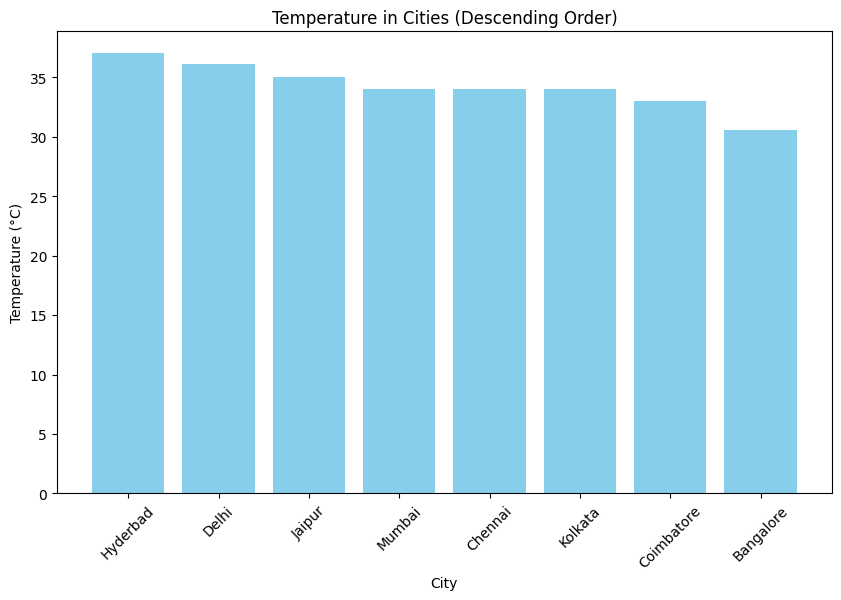

In [16]:
import requests
plt.figure(figsize=(10, 6))
# Sort the DataFrame by 'temperature' in descending order
sorted_df = weather_df.sort_values(by='temperature', ascending=False)
plt.bar(sorted_df['city'], sorted_df['temperature'], color='skyblue')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.title('Temperature in Cities ')
plt.xticks(rotation=45)
plt.show()

### Temperature vs. Feels Like Temperature with Humidity

This scatter plot visualizes the relationship between the actual `temperature` and the `feels_like` temperature. The color of each point represents the `humidity` level, allowing us to observe if higher humidity correlates with a larger difference between actual and perceived temperatures.

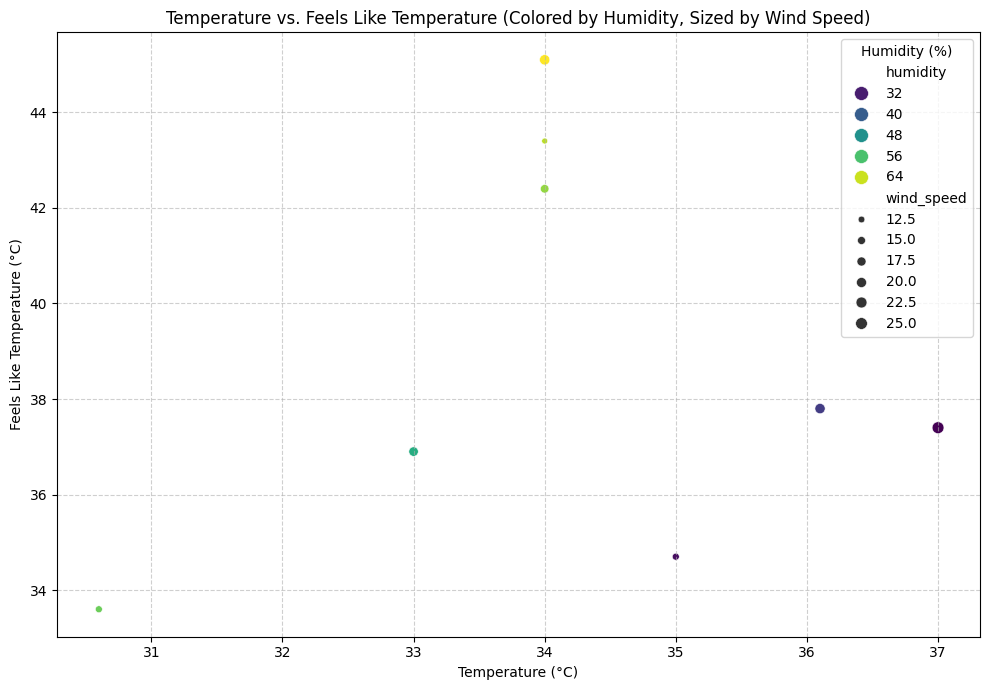

In [18]:
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=weather_df,
    x='temperature',
    y='feels_like',
    hue='humidity',
    size='wind_speed', # Optionally add wind_speed as size to show another dimension
    palette='viridis', # Choose a color palette
    s=100 # Set default size for scatter points if 'size' is not used or to make points visible
)

plt.title('Temperature vs. Feels Like Temperature (Colored by Humidity, Sized by Wind Speed)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Feels Like Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Humidity (%)')
plt.tight_layout()
plt.show()